# Chapter 12 — Least Squares Applications

## Learning Objectives

This notebook covers polynomial regression, multicollinearity, regularization, and grid search for model parameters.

## Theoretical Explanation

Least squares is not limited to straight lines. By transforming predictors into polynomial features, linear least squares can fit nonlinear curves. However, higher-degree models may overfit. Multicollinearity makes the design matrix unstable because predictors contain redundant information. Regularization stabilizes the solution by shifting `X.T @ X`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import norm, matrix_rank

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Polynomial Regression

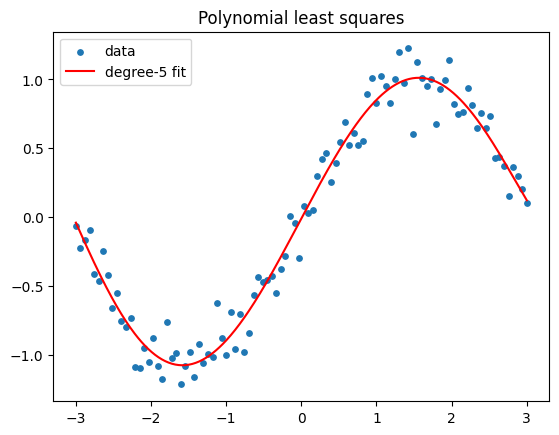

In [2]:
rng = np.random.RandomState(RANDOM_STATE)
x = np.linspace(-3,3,100)
y = np.sin(x) + rng.normal(0,.15,len(x))
X_poly = np.column_stack([x**i for i in range(6)])
beta = np.linalg.pinv(X_poly) @ y
line = np.linspace(-3,3,400)
Line_poly = np.column_stack([line**i for i in range(6)])
yp = Line_poly @ beta
plt.scatter(x,y,s=15,label='data')
plt.plot(line,yp,color='red',label='degree-5 fit')
plt.legend(); plt.title('Polynomial least squares')
plt.show()

### Output Interpretation

Polynomial features allow a linear model in transformed feature space to represent nonlinear patterns in the original input space.

## 2. Regularization for Multicollinearity

In [3]:
X = np.column_stack([np.ones_like(x), x, x + rng.normal(0,.01,len(x))])
y_lin = 1 + 2*x + rng.normal(0,.3,len(x))
cond = np.linalg.cond(X.T @ X)
for lam in [0, .1, 1]:
    beta_reg = np.linalg.inv(X.T@X + lam*np.eye(X.shape[1])) @ X.T @ y_lin
    print('lambda:', lam, 'beta:', np.round(beta_reg,3))
print('condition number of X.T@X:', round(cond,2))

lambda: 0 beta: [ 1.02   3.214 -1.231]
lambda: 0.1 beta: [1.018 1.087 0.896]
lambda: 1 beta: [1.009 1.    0.98 ]
condition number of X.T@X: 135984.44


### Output Interpretation

Correlated predictors make coefficient estimates unstable. Regularization reduces instability by penalizing large coefficients and improving numerical conditioning.

## Extended Study Notes

The central learning objective is not only to run code, but to connect the numerical result back to the linear algebra idea. In applied data science, vectors and matrices are not abstract objects only; they are the representation layer for observations, features, images, time series, model parameters, transformations, and decompositions.

A professional workflow should always include sanity checks. For example, reconstructed matrices should be compared with the original matrix, orthogonal matrices should be checked with `Q.T @ Q`, inverse computations should be checked against the identity matrix, and least-squares predictions should be inspected through residuals. These checks make the notebook academically stronger and reduce the risk of blindly trusting a black-box function.

## Chapter Summary

This notebook reproduces the core concept of the chapter using original/adapted Python examples. The code is intentionally compact but runnable, and the surrounding explanation focuses on conceptual understanding, interpretation, and practical relevance for data science.

## Key Takeaways

- Linear algebra concepts become clearer when formulas, geometry, and code are studied together.
- NumPy provides efficient implementations, but understanding the underlying math helps prevent misuse.
- Shape, rank, orientation, and numerical stability are recurring concerns in applied linear algebra.
- Every output should be interpreted as evidence of a mathematical property, not merely as a printed result.